Loading sample submission (assumed ground truth)...
Sample submission loaded. Shape: (3600, 2)
Sample submission columns: ['Id', 'Class']
Sample targets loaded.

--- Evaluating submission_knn.csv ---
  Loaded model submission. Shape: (3600, 2)
  Model submission columns: ['Id', 'target']
  Could not calculate ROC AUC: axis 1 is out of bounds for array of dimension 1. It might require probability scores or specific label encoding.
  Accuracy (Classification): 0.4919
  F1 Score (Classification, macro): 0.4482
  ROC AUC (Classification, macro, ovr): nan

--- Evaluating submission_naivebayes.csv ---
  Loaded model submission. Shape: (3600, 2)
  Model submission columns: ['Id', 'target']
  Could not calculate ROC AUC: axis 1 is out of bounds for array of dimension 1. It might require probability scores or specific label encoding.
  Accuracy (Classification): 0.4808
  F1 Score (Classification, macro): 0.4226
  ROC AUC (Classification, macro, ovr): nan

--- Evaluating submission_randomforest.

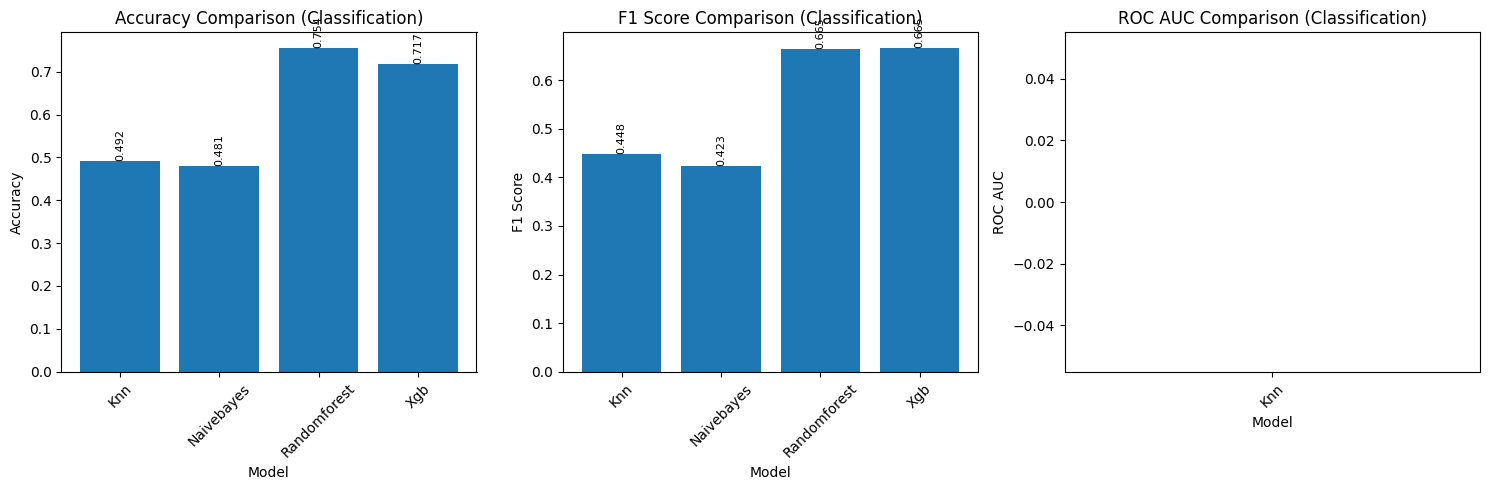


Accuracy evaluation and graphing complete (if sample submission was available).


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import os

# --- Configuration ---
sample_submission_file = 'sample_submission.csv' # Ground truth or standard format
submission_dir = 'submissions'                   # Directory containing model predictions
# target_column = 'target'                        # Determine dynamically

# --- Load Sample Submission (Ground Truth or Standard Format) ---
print("Loading sample submission (assumed ground truth)...")
sample_df = None
try:
    if os.path.exists(sample_submission_file) and os.path.getsize(sample_submission_file) > 0:
        sample_df = pd.read_csv(sample_submission_file)
        print(f"Sample submission loaded. Shape: {sample_df.shape}")
        print(f"Sample submission columns: {list(sample_df.columns)}")
        if len(sample_df.columns) < 2:
            print("Error: Sample submission must have at least an ID column and a target column.")
            sample_df = None
        else:
            sample_ids = sample_df.iloc[:, 0] # Assuming first column is ID
            sample_targets = sample_df.iloc[:, 1] # Assuming second column is the target
            # Or, if the target column has a specific name like 'target':
            # if 'target' in sample_df.columns:
            #     sample_targets = sample_df['target']
            # else:
            #     # Use the second column if 'target' is not named
            #     sample_targets = sample_df.iloc[:, 1]
            print("Sample targets loaded.")
    else:
        print(f"Error or file empty: {sample_submission_file} not found or is empty. Cannot calculate accuracy.")
        print("The sample submission file provided seems to be empty.")
        print("Accuracy calculation and graphing require a non-empty sample submission file with ground truth.")
        # exit() # Commenting out exit to potentially print a message if submissions exist
        sample_targets = None
        sample_ids = None
except Exception as e:
    print(f"Error loading sample submission: {e}")
    sample_targets = None
    sample_ids = None


if sample_targets is not None and sample_ids is not None:
    # --- Iterate through submission files in the directory ---
    submission_files = [f for f in os.listdir(submission_dir) if f.startswith('submission_') and f.endswith('.csv')]

    if not submission_files:
        print(f"No submission files found in '{submission_dir}'. Run 'train_models.py' first.")
    else:
        results = {}
        for submission_file in submission_files:
            submission_path = os.path.join(submission_dir, submission_file)
            print(f"\n--- Evaluating {submission_file} ---")

            try:
                # Load the model's submission
                model_df = pd.read_csv(submission_path)
                print(f"  Loaded model submission. Shape: {model_df.shape}")
                print(f"  Model submission columns: {list(model_df.columns)}")

                # --- Align Predictions with Sample Submission ---
                if len(model_df) != len(sample_df):
                     print(f"  Error: Shape mismatch. Sample: {len(sample_df)}, Model: {len(model_df)}")
                     continue

                # Identify the prediction column in the model's submission
                # It should be the 'target' column as saved by train_models.py
                if 'target' in model_df.columns:
                    model_predictions = model_df['target']
                elif len(model_df.columns) > 1:
                    # Fallback: use the second column if 'target' not found
                    model_predictions = model_df.iloc[:, 1]
                else:
                    print(f"  Error: Model submission {submission_file} does not have a prediction column.")
                    continue

                # --- Determine Problem Type and Calculate Metrics ---
                # Infer based on sample submission target type
                if sample_targets.dtype == 'object' or isinstance(sample_targets.dtype, pd.CategoricalDtype) or len(sample_targets.unique()) <= 20: # Heuristic for classification
                     # Classification
                     accuracy = accuracy_score(sample_targets, model_predictions)
                     f1 = f1_score(sample_targets, model_predictions, average='macro') # Use macro average for multiclass
                     try:
                         # ROC AUC requires probability scores for multiclass, or specific handling for labels.
                         # If labels are integers, we can use 'ovr' (One-vs-Rest).
                         # This might fail if labels are strings, in which case, convert to numeric or handle differently.
                         roc_auc = roc_auc_score(sample_targets, model_predictions, average='macro', multi_class='ovr')
                     except ValueError as e:
                         print(f"  Could not calculate ROC AUC: {e}. It might require probability scores or specific label encoding.")
                         roc_auc = float('nan') # Set to NaN if calculation fails

                     print(f"  Accuracy (Classification): {accuracy:.4f}")
                     print(f"  F1 Score (Classification, macro): {f1:.4f}")
                     print(f"  ROC AUC (Classification, macro, ovr): {roc_auc:.4f}")

                     # Store results for graphing
                     model_name = submission_file.replace('submission_', '').replace('.csv', '').capitalize()
                     results[model_name] = {
                         'Accuracy': accuracy,
                         'F1_Score': f1,
                         'ROC_AUC': roc_auc
                     }
                else:
                     # Regression
                     mse = mean_squared_error(sample_targets, model_predictions)
                     r2 = r2_score(sample_targets, model_predictions)
                     print(f"  MSE (Regression): {mse:.4f}")
                     print(f"  R2 Score (Regression): {r2:.4f}")
                     # Store results for graphing (regression metrics)
                     model_name = submission_file.replace('submission_', '').replace('.csv', '').capitalize()
                     results[model_name] = {
                         'MSE': mse,
                         'R2_Score': r2
                     }

            except Exception as e:
                print(f"  Error evaluating {submission_file}: {e}")

        if results:
            print("\n--- Plotting Results ---")
            # Determine if classification or regression results were collected
            if 'Accuracy' in list(results.values())[0]:
                 # Classification metrics
                 metrics_to_plot = ['Accuracy', 'F1_Score', 'ROC_AUC']
                 metric_names = ['Accuracy', 'F1 Score', 'ROC AUC']
                 title_suffix = " (Classification)"
            else:
                 # Regression metrics
                 metrics_to_plot = ['MSE', 'R2_Score']
                 metric_names = ['MSE', 'R2 Score']
                 title_suffix = " (Regression)"

            fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 5))
            if len(metrics_to_plot) == 1: # Handle single subplot case
                axes = [axes]

            model_names = list(results.keys())
            for i, (metric_key, metric_display_name) in enumerate(zip(metrics_to_plot, metric_names)):
                 ax = axes[i]
                 values = [results[name][metric_key] for name in model_names]
                 ax.bar(model_names, values)
                 ax.set_title(f'{metric_display_name} Comparison{title_suffix}')
                 ax.set_ylabel(metric_display_name)
                 ax.set_xlabel('Model')
                 ax.tick_params(axis='x', rotation=45)
                 # Add value labels on top of bars
                 for j, v in enumerate(values):
                     ax.text(j, v, f'{v:.3f}', ha='center', va='bottom' if metric_key != 'MSE' else 'top', rotation=90, fontsize=8) # Rotate text for better fit, flip for MSE

            plt.tight_layout()
            plt.show()
            print("\nAccuracy evaluation and graphing complete (if sample submission was available).")
        else:
            print("\nNo results to plot. Check if model submissions were evaluated successfully.")

else:
    print("\nSkipping accuracy evaluation and graphing because the sample submission file is empty or invalid.")
